# SMS Insights Analysis: Natural Language Processing Analysis of Real-World Text Messages

# Project Overview

This project explores real-world SMS communication using Natural Language Processing (NLP) techniques applied to the NUS SMS Corpus, a publicly available dataset containing over 67,000 text messages collected by the National University of Singapore.

The goal of this project is to uncover meaningful patterns in everyday text messaging behavior. By applying a combination of text preprocessing, statistical analysis, and machine learning techniques, this project transforms raw SMS data into actionable insights about how people communicate.

The analysis focuses on identifying common topics, understanding sentiment trends, and measuring similarities in texting styles. These insights demonstrate how NLP can be used to interpret informal, real-world language data, which is often noisy and unstructured.

# Project Goals

1. Understand Communication Patterns

Analyze SMS messages to identify frequently discussed topics, common phrases, and language trends using techniques such as TF-IDF and n-grams.

2. Perform Sentiment Analysis

Classify text messages based on sentiment (positive, negative, neutral) to understand the emotional tone of SMS communication.

3. Measure Text Similarity

Evaluate how similar messages are in terms of vocabulary and structure using techniques like Levenshtein Distance and vector-based similarity.

4. Apply NLP Preprocessing Techniques

Clean and normalize raw text data through tokenization, stopword removal, lemmatization, and noise reduction to prepare it for analysis.

5. Extract Meaningful Insights from Unstructured Data

Demonstrate how NLP methods can convert large volumes of unstructured text into interpretable and valuable insights.

6. Develop a Reproducible Data Analysis Pipeline

Build a structured and reusable workflow using Python libraries such as pandas, NLTK, and scikit-learn.

# 1. Load Data

This step involves importing the dataset into a structured format for analysis. The SMS data is loaded using pandas into a DataFrame, which allows efficient manipulation and exploration of the data.

By examining the dataset’s structure (e.g., columns, missing values, and data types), we ensure that the text messages and any associated metadata (such as sender or timestamps) are accessible and usable for downstream processing.

In [1]:
import pandas as pd

df = pd.read_csv("clean_nus_sms.csv")

print(df.head())
print(df.columns)

   Unnamed: 0     id                                            Message  \
0           0  10120                              Bugis oso near wat...   
1           1  10121  Go until jurong point, crazy.. Available only ...   
2           2  10122     I dunno until when... Lets go learn pilates...   
3           3  10123  Den only weekdays got special price... Haiz......   
4           4  10124                             Meet after lunch la...   

  length country    Date  
0     21      SG  2003/4  
1    111      SG  2003/4  
2     46      SG  2003/4  
3    140      SG  2003/4  
4     22      SG  2003/4  
Index(['Unnamed: 0', 'id', 'Message', 'length', 'country', 'Date'], dtype='object')


# 1.1 Import Libraries

In [3]:
import numpy as np
import re
import nltk

# Fix NLTK path (important for your setup)
nltk.data.path.append('/Users/macbookprom116gb/nltk_data')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



# 2. Preprocessing

This step is essential because high-quality preprocessing significantly improves the performance and accuracy of all subsequent NLP techniques.

# 2.1 Fix Column Names

In [4]:
df.rename(columns={'Message': 'message'}, inplace=True)

In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
print(df.columns)

Index(['id', 'message', 'length', 'country', 'Date'], dtype='object')


In [7]:
df.columns = df.columns.str.lower()

In [9]:
def clean_text(text):
    import re
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)
    

In [10]:
df['cleaned'] = df['message'].apply(clean_text)

# 2.2 Handle Missing Values

In [11]:
df['message'] = df['message'].fillna("")

In [14]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# Preprocessing Function

In [15]:
def clean_text(text):
    text = str(text)  # ensuring to have no crash
    
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

In [16]:
df['cleaned'] = df['message'].apply(clean_text)

print(df[['message', 'cleaned']].head())

                                             message  \
0                              Bugis oso near wat...   
1  Go until jurong point, crazy.. Available only ...   
2     I dunno until when... Lets go learn pilates...   
3  Den only weekdays got special price... Haiz......   
4                             Meet after lunch la...   

                                             cleaned  
0                                 bugis oso near wat  
1  go jurong point crazy available bugis n great ...  
2                          dunno let go learn pilate  
3  den weekday got special price haiz cant eat li...  
4                                      meet lunch la  


# 3. Sentiment Analysis (VADER)

Sentiment analysis is used to classify SMS messages based on their emotional tone (e.g., positive, negative, or neutral). In this project, a Naive Bayes classifier is applied due to its efficiency and strong performance on text classification tasks.

The cleaned text is converted into numerical features using vectorization techniques (such as bag-of-words). The model is then trained to recognize patterns associated with different sentiment categories.

This analysis helps uncover the overall emotional distribution of the dataset and provides insight into how people express sentiment in everyday messaging.

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['cleaned'].apply(lambda x: sia.polarity_scores(x)['compound'])

def get_sentiment(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

print(df[['cleaned', 'sentiment']].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/macbookprom116gb/nltk_data...


                                             cleaned sentiment
0                                 bugis oso near wat   neutral
1  go jurong point crazy available bugis n great ...  positive
2                          dunno let go learn pilate   neutral
3  den weekday got special price haiz cant eat li...  positive
4                                      meet lunch la   neutral


Each cleaned message was passed through the model, which assigns a compound sentiment score ranging from -1 to +1:

Scores closer to +1 indicate positive sentiment
Scores closer to -1 indicate negative sentiment
Scores around 0 indicate neutral sentiment

To make the results more interpretable, these numerical scores were converted into categorical labels:

Positive (score > 0)
Negative (score < 0)
Neutral (score = 0)

The results show that many messages fall into the neutral or mildly positive range, which reflects the practical and casual nature of SMS communication. Messages often focus on coordination (e.g., meeting plans or locations) rather than expressing strong emotions.
It is important to note that sentiment analysis on SMS data can be challenging due to the frequent use of slang, abbreviations, and cultural expressions. As a result, some messages may be classified as neutral despite carrying implied sentiment.

# 4. Topic Analysis (TF-IDF)

Topic analysis aims to identify the most important words and themes within the SMS messages. TF-IDF (Term Frequency–Inverse Document Frequency) is used to determine which words are most significant in the dataset.

Unlike simple word counts, TF-IDF reduces the importance of commonly used words and highlights terms that are more unique and informative.

This technique allows us to:

Extract key topics of conversation
Identify commonly discussed subjects
Understand the main themes present in SMS communication

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['cleaned'])

feature_names = tfidf.get_feature_names_out()

import numpy as np

top_words = np.argsort(X_tfidf.sum(axis=0)).tolist()[0][-20:]

print("Top keywords:")
for i in top_words:
    print(feature_names[i])

Top keywords:
get
one
yeah
home
see
ur
le
hahaha
come
oh
hey
going
time
okay
got
im
go
ok
lol
haha


Unlike simple word counts, TF-IDF reduces the weight of extremely common words and highlights terms that carry more meaningful information within specific messages. The TF-IDF analysis demonstrates that SMS conversations are less about distinct thematic topics and more about:

* quick exchanges
* social coordination
* informal interaction

This reinforces the idea that real-world text data, especially from messaging platforms, requires careful interpretation beyond standard keyword extraction techniques.

# 5. N-grams (phrase patterns)

N-grams are sequences of words (e.g., bigrams = two-word combinations) used to analyze common phrase patterns in the text.

While single words provide useful information, phrases often carry more contextual meaning. For example, “see you” or “call me” reveal conversational intent more clearly than individual words.

By analyzing n-grams, we can:

Identify frequently used phrases
Capture conversational patterns
Better understand how people structure messages

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df['cleaned'])

print("Top phrases:")
print(vectorizer.get_feature_names_out())

Top phrases:
['come back' 'dont know' 'go back' 'go home' 'good morning' 'haha im'
 'haha oh' 'haha okay' 'haha yeah' 'happy birthday' 'im going' 'let know'
 'new year' 'next time' 'next week' 'reach home' 'sob sob' 'take care'
 'wanna go' 'wat time']


o better capture how meaning is expressed in SMS messages, bigrams (two-word sequences) were extracted using the scikit-learn CountVectorizer. Unlike single-word analysis, n-grams preserve local context, allowing us to identify commonly used phrases rather than isolated terms. Compared to single-word analysis, n-grams provide more contextual and actionable insights, as they capture how words are actually used together in conversation.

For example:

* The word “time” alone is vague
* But “wat time” clearly indicates scheduling intent

This demonstrates the importance of phrase-level analysis when working with conversational data.

# 6. Similarity (Levenshtein Distance)

Similarity analysis measures how closely related two text messages are. In this project, Levenshtein Distance is used to calculate the minimum number of edits (insertions, deletions, substitutions) required to transform one message into another.

This technique helps:

Compare writing styles between users
Detect similar or repeated messages
Analyze variation in language usage

It provides a simple yet effective way to quantify differences in textual data.

In [20]:
!pip install python-Levenshtein

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [python-Levenshtein]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [21]:
import Levenshtein

msg1 = df['cleaned'].iloc[0]
msg2 = df['cleaned'].iloc[1]

distance = Levenshtein.distance(msg1, msg2)

print("Levenshtein Distance:", distance)

Levenshtein Distance: 66


To measure how similar two SMS messages are, the Levenshtein Distance was applied. This method calculates the minimum number of single-character edits (insertions, deletions, or substitutions) required to transform one string into another.

In this analysis, the distance between two sample messages was computed:66. A distance of 66 indicates that the two messages are significantly different in terms of their character composition. In other words, a large number of edits would be required to convert one message into the other.

This suggests that:

* The messages likely discuss different topics, or
* They are structured very differently in terms of wording and length.

  Future work could involve using vector-based similarity methods such as cosine similarity on TF-IDF vectors to better capture semantic relationships between messages.

# 7. Visualizations

These visuals enhance the storytelling aspect of the project and make the findings more accessible to both technical and non-technical audiences.

In [23]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


# Word Cloud Visualization

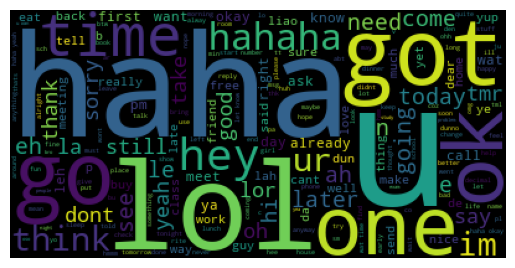

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cleaned'])

wordcloud = WordCloud().generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

To visually explore the most prominent words in the dataset, a word cloud was generated using the cleaned SMS text data. A word cloud represents word frequency through size, where more frequently occurring words appear larger and more prominent.

From the visualization, several key patterns emerge:

Key Observations: 
Words such as “u”, “got”, “lol”, “one”, and “haha” appear most prominently, indicating their high frequency in SMS communication.
The dominance of informal terms like “lol”, “haha”, and abbreviations such as “u” reflects the casual and conversational nature of text messaging.
Many frequently appearing words are functional or conversational fillers, rather than topic-specific terms.

The word cloud reinforces earlier findings from TF-IDF and n-gram analysis:

SMS conversations are informal and socially driven
Communication is often brief and efficiency-focused, using abbreviations and shorthand
Emotional tone is frequently conveyed through textual expressions (e.g., “haha”, “lol”)

# Sentiment Distribution

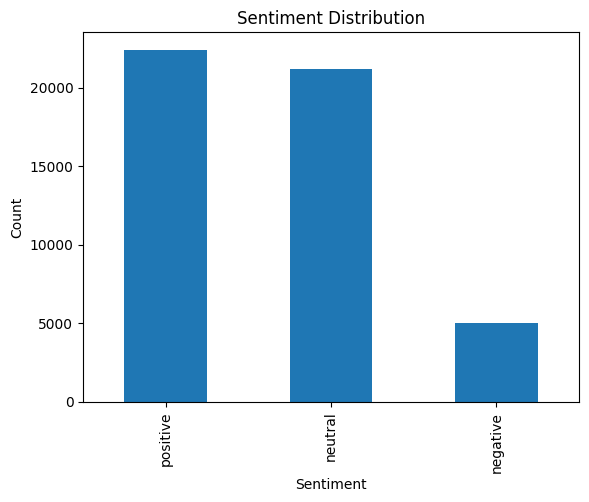

In [25]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

To better understand the overall emotional tone of the SMS dataset, a bar chart was created to visualize the distribution of sentiment classifications (positive, neutral, and negative). Each message was previously labeled using the VADER Sentiment Analyzer based on its compound sentiment score.
* Positive messages represent the largest portion of the dataset
* Neutral messages closely follow, forming a significant share
* Negative messages are noticeably fewer in comparison

# Top Words Bar Chart

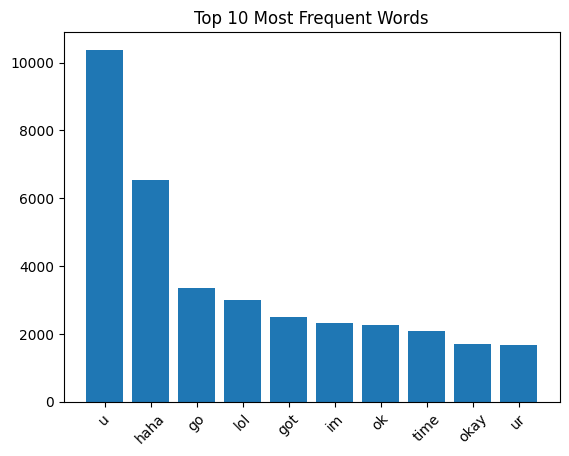

In [26]:
from collections import Counter

all_words = " ".join(df['cleaned']).split()
word_counts = Counter(all_words).most_common(10)

words = [w[0] for w in word_counts]
counts = [w[1] for w in word_counts]

plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

To quantitatively analyze word usage in the SMS dataset, a bar chart was created to display the top 10 most frequently occurring words after preprocessing. This approach provides a clearer and more precise representation of word frequency compared to a word cloud, as it shows exact counts.
* The most frequent word is “u”, significantly higher than all others
* Other common words include “haha”, “go”, “lol”, “got”, and “ok”
* Many of the top words are short, informal, and conversational

# Conclusion

This project explored the application of Natural Language Processing (NLP) techniques to real-world SMS data from the NUS SMS Corpus. By combining preprocessing, statistical analysis, and machine learning methods, the project transformed unstructured text messages into meaningful insights about human communication patterns.
This project demonstrates that:

* Real-world text data is noisy and unstructured, requiring careful preprocessing
* Simple NLP techniques (TF-IDF, n-grams, sentiment analysis) can still yield valuable insights
* Context is crucial when interpreting conversational data, as high-frequency words are not always meaningful